In [4]:
!pip install qiskit qiskit-aer qiskit[visualization] qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 85.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [qiskit-ibm-runtime]iskit-ibm-runtime]es]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
from itertools import islice

In [2]:
# Initializing the backend
service = QiskitRuntimeService()

# https://quantum.cloud.ibm.com/docs/en/guides/hello-world
# https://cloud.ibm.com/iam/apikeys?bss_account=952fc7dad0544862a921fee4630e8563

AccountNotFoundError: "Unable to find account. Please make sure an account with the channel name 'ibm_quantum_platform' is saved."

In [ ]:
# Fake
from qiskit.primitives import StatevectorSampler
sampler = StatevectorSampler()

In [ ]:
# Real
'''
from qiskit_ibm_runtime import SamplerV2 as Sampler
# Select a real backend
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(backend)
'''

In [2]:
backend = service.least_busy(operational=True, simulator=True)
backend.name

In [3]:
# Initialize quantum circuit with one qubit and one classical bit
circ = QuantumCircuit(1, 1)

# Apply Hadamard gate to qubit at the index 0
circ.h(0)

# Measure the qubit at index 0 and store in the classical bit at index 0
circ.measure(0,0)

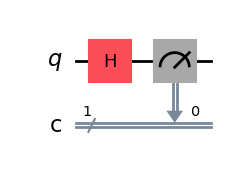

In [4]:
# Draw the quantum circuit using matplotlib
circ.draw("mpl")

In [5]:
print("Details of Classical Register: ", circ.cregs)
# Details of Classical Register:  [ClassicalRegister(1, 'c')]

print("Details of Quantum Register: ", circ.qregs)
# Details of Quantum Register:  [QuantumRegister(1, 'q')]

Details of Classical Register:  [ClassicalRegister(1, 'c')]
Details of Quantum Register:  [QuantumRegister(1, 'q')]


In [1]:
# Transpile 
circ = transpile(circ, backend)

NameError: name 'QiskitRuntimeService' is not defined

In [13]:
# Run the circuit on the simulator 10k times 
result = backend.run(circ, shots = 10000).result()

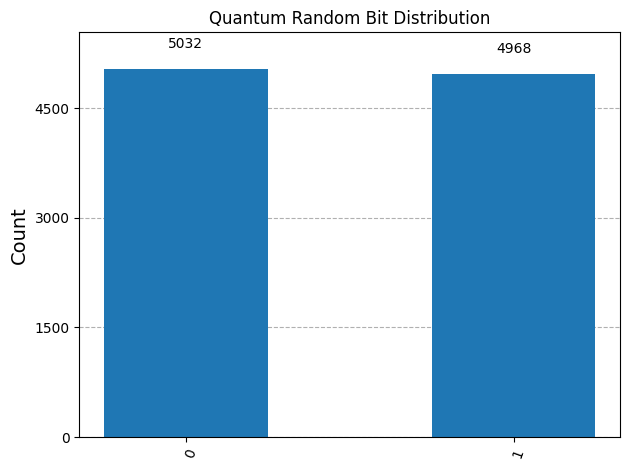

In [8]:
# Get the data of our experiment
counts = result.get_counts(circ)

# Plot the data in a histogram
plot_histogram(counts, title='Quantum Random Bit Distribution')

In [9]:
# Run the simulator 640000 times to generate 1000 64-bit number
result = backend.run(circ, shots=64*10000, memory=True).result()

# Extract the results from memory in a list and print them
memory = result.get_memory(circ)
# print(memory)

In [10]:

a = memory  
n = 64  

it = iter(a) 
res = [str(int(''.join((islice(it, n))) , 2)) for _ in range((len(a) + n - 1) // n)]
print(len(res))

10000


In [11]:
with open("simulated.txt", "w") as f:
    f.write("\n".join(res))
    